### Skapar dataset med och utan de kategoriska features

In [1]:
import pandas as pd
df = pd.read_csv('revised_data.csv', index_col=0)
df = df.drop(columns='id') # Tar bort id eftersom id = index, onödig feature
df['gender'] = df['gender'].apply(lambda x: 'Woman' if x == 1 else 'Man') # Eftersom det är en kategorisk variabel gör jag den mer läsbar
yes_cat = df.drop(columns=[ 'ap_hi', 'ap_lo', 'height', 'weight', 'BMI'])
no_cat = df.drop(columns=['BMI_class', 'blood_pressure', 'height', 'weight'])

#One hot encoding
yes_cat = pd.get_dummies(yes_cat, columns=['BMI_class', 'blood_pressure', 'gender'])
no_cat = pd.get_dummies(no_cat, columns=['gender'])


### Använder custom class för att ta fram modeller att testa datan

In [2]:
from model_class import model_selection
#Initierar två klasser med och utan kategoriska features
X = yes_cat.drop(columns='cardio')
y = yes_cat['cardio']
#Initierar med skalering och test_split funktion
with_cat = model_selection(X, y, autoscale=True, autosplit=True)
X = no_cat.drop(columns='cardio')
y = no_cat['cardio']
#Initierar med skalering och test_split funktion
without_cat = model_selection(X, y, autoscale=True, autosplit=True)


## Val av modeller
##### Eftersom detta är ett kvalificeringsproblem väljer jag följande:
- KNN
- Logistisk Regression
- Decision Trees
- Ridge Classifier
- RandomForestClassifier

In [ ]:
#Skapar Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

#Ihopklistrad och omskriven kod. Ursprungligen från ChatGpt och sklearn
#Definiera parametrar med respektive modell
param_grid = [
    {
        'classifier': [KNeighborsClassifier()],
        'classifier__n_neighbors': [1,3],
    },
    {
        'classifier': [LogisticRegression()],
        'classifier__C': [0.01, 0.1, 1]
    },
    {
        'classifier': [DecisionTreeClassifier()],
        'classifier__max_depth': [1,2]
    },
    {
        'classifier': [RidgeClassifier()],
        'classifier__alpha': [0.01, 0.1, 1]
    },
    {
        'classifier': [RandomForestClassifier()],
        'classifier__max_depth': [1, 2],
    }
]
print('With Categories:')
with_cat.GridCV_pipeline_fit(param_grid=param_grid)
print('Without Categories:')
without_cat.GridCV_pipeline_fit(param_grid=param_grid)
#Tar ca 50 sekunder, RandomForest är långsam på cpu

With Categories:
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Bästa modellen: Pipeline(steps=[('classifier', LogisticRegression(C=1))])
Bästa score: 0.6960257291774914
Without Categories:
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Bästa modellen: Pipeline(steps=[('classifier', LogisticRegression(C=1))])
Bästa score: 0.7239085549023105


With category
              precision    recall  f1-score   support

           0       0.68      0.75      0.71     10285
           1       0.71      0.63      0.67     10065

    accuracy                           0.69     20350
   macro avg       0.70      0.69      0.69     20350
weighted avg       0.70      0.69      0.69     20350

Without category
              precision    recall  f1-score   support

           0       0.72      0.77      0.74     10534
           1       0.73      0.67      0.70      9816

    accuracy                           0.73     20350
   macro avg       0.73      0.72      0.72     20350
weighted avg       0.73      0.73      0.72     20350



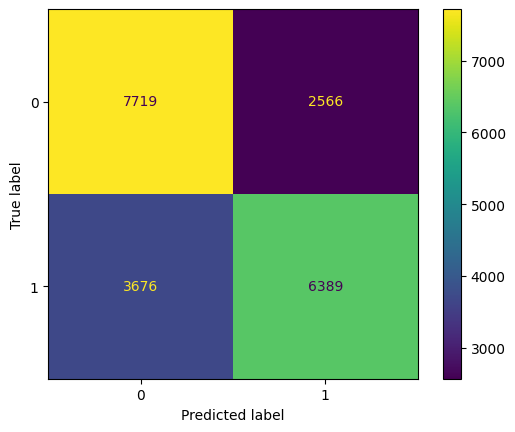

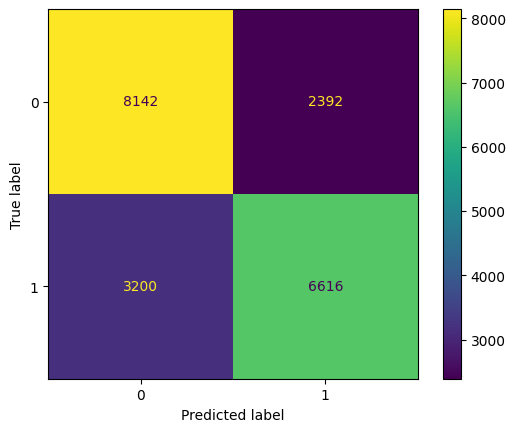

In [4]:
#Förutse y_hat från X_test
print('With category')
with_cat.predict_score()
print('Without category')
without_cat.predict_score()

- Eftersom datasetet utan kategorier har presterat bättre både i träning och i validering väljer jag att fortsätta med den

In [5]:
#Hämtar bästa parametrar för varje model
score_withoutcat = without_cat.get_all_best_params()

print(score_withoutcat)

{'classifier': KNeighborsClassifier(), 'classifier__n_neighbors': 3}, score: 0.6717496522537926
{'classifier': LogisticRegression(), 'classifier__C': 1}, score: 0.7239085549023105
{'classifier': DecisionTreeClassifier(), 'classifier__max_depth': 1}, score: 0.7079339938861338
{'classifier': RidgeClassifier(), 'classifier__alpha': 0.01}, score: 0.7231098252406165
{'classifier': RandomForestClassifier(), 'classifier__max_depth': 2}, score: 0.7129441284050162



- Nu är de bästa parametrar kända från CrossValidation och sätter in dessa i en VoteClassifier

In [11]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report
vclf = VotingClassifier(
    [('knn', KNeighborsClassifier(n_neighbors=3)),
     ('logr',LogisticRegression(C=1)),
     ('dtree', DecisionTreeClassifier(max_depth=1)),
     ('Rreg', RidgeClassifier(alpha=0.01)),
     ('Rforest', RandomForestClassifier(max_depth=2))], voting='hard'
)
vclf.fit(without_cat.X_train, without_cat.y_train)
y_hat = vclf.predict(without_cat.X_test)
print(classification_report(without_cat.y_test, y_hat))

              precision    recall  f1-score   support

           0       0.71      0.79      0.75     10534
           1       0.74      0.65      0.70      9816

    accuracy                           0.72     20350
   macro avg       0.73      0.72      0.72     20350
weighted avg       0.73      0.72      0.72     20350



### Slutsatser
- Voting Classifier resultera i något sämre accuracy än Logistic Regression som Crossvalidation tog fram med bästa hyperparameter.
- Analysen utifrån resultatet är att en Voting Classifier kan försämra accuracy om du inkluderar modeller med sämre accuracy även för att få en "bredare uppfattning"
- Därför kan det vara rimligt att hålla sig till en modell som är överlägsen andra modeller.
- Om man däremot har modeller som presterar lika bra kan Voting Classifier vara att föredra
- I detta fall var den ej kategoriska datan mer relevant och även den modell som prestera bäst var Logistic Regression med den valda C=1.
